# Basic Task

TODO: Validate generated arrays
TODO: Need logic when choosing next state to calculate possible next states (given that the robot can go left, right, forward, backward)
TODO: Need to add positions in reward matrix for wall collision penalty

We present a 8 x 8 grid environment, with coordinates ranging from (0,0) to (7,7). These will represent the agent states.

Obstacles are presented at the following locations, with their corresponding abbreviations:
- O_1: (2,0)
- O_2: (1,2)
- O_3: (0,4)
- O_41: (1,6)
- O_42: (2,6)
- O_5: (4,4)
- O_6: (5,1)
- O_71: (5,6)
- O_72: (6,6)
- O_8: (7,2)

The agent begins at (0,0) and leaves the room at (7,7).

The obstacles (O_n) and pickup objects (P_m) are placed at various locations to complicate the environment and ensure the robot does not move in straightforward paths.

The rewards and penalties for the agent are outlined as follows:
- Reward: Landing on a blank square (BS)
- Reward: Picking up an object (PO)
- Penalty: Landing on a water spill (WS)
- Penalty: Landing on a charger cable (CC)
- Penalty: Colliding with a wall (CW)
- Penalty: Collding with an object (CO)
- Reward (final reward): Reaching the exit (RE)
- Reward: Having picked up a number objects above a set threshold (POTH)
[- Moving left when the ceiling fan is activated]

We program the grid such that the robot cannot leave until all objects are collected _and_ the robot reaches the exit.

This extends the set to be of the following format:
(coordinate, direction, pickup_state_after_action)

In [ ]:
# Import necessary libraries
import numpy as np

In [ ]:
# State space: 8 x 8 grid

# Define the reward and penalty values
#BLANK_SQUARE = 10 ## CHANGED: FROM 20 TO 10
PICKUP_OBJECT = 25 # CHANGED: FROM 10 TO 25; There are 4 objects in total to collect
#PICKUP_ABOVE_THRESH = 75 # CHANGED: FROM 25 TO 75; # Only acquired if pickup_count > threshold

#PICKUP_COUNT = 0 # Number of objects roomba has picked up
#PICKUP_THRESHOLD = 2 # Minimum number of pickups to receive an extra reward
#TOTAL_OBJECTS = 4 # Total number of possible objects for agent to pick up

WALL_COLLIDE = -10 #-10
OBJECT_COLLIDE = -5 #-20
WATER = -20
CABLE = -20
BLANK_SQUARE = -1 # Incenitivises the agent to find the objects to pick up

FINAL_REWARD = 200 # Must go to end and pick up all three objects


# Actions: define currently as L, R, F, B (left, right, forward, backward)
#          enables mapping of state action pairs
A = ['L', 'R', 'F', 'B']

# Define the states and actions
# States: valid coordinates within grid
#S = [(x,y) for y in range(8) for x in range(8) for a in range(len(A))]

# Rewards matrix: created from the state-action pairs
#R =  np.array([[np.nan for a in A] for s in S])

# For simplicity, hard-code the dimension
# Number of rows = GRID_SIZE * NUM_PICKUP_STATES
# Number of columns = NUM_DIRECTIONS
GRID_SIZE = 64
NUM_PICKUP_STATES = 8
NUM_DIRECTIONS = 4
# Rewards matrix: initialise each position as NaN
REWARDS_MATRIX_ROW_NUM = GRID_SIZE * NUM_PICKUP_STATES
REWARDS_MATRIX_COL_NUM = NUM_DIRECTIONS
# Ref: https://stackoverflow.com/questions/1704823/create-numpy-matrix-filled-with-nans
R = np.empty((REWARDS_MATRIX_ROW_NUM, REWARDS_MATRIX_COL_NUM))

# Validate the rewards matrix shape
R.shape

(512, 4)

In [ ]:
pickup_locs = {'P_1': (1,3), 'P_2': (1,7), 'P_3': (6,4)}

### Coordinate System for Rewards Matrix
The row is the coordinate: (x,y) converted to one digit (0 to 63 for (0,0) to (8,8)).
Important consideration: not every position in the rewards grid will correspond to a valid state-action pair (e.g. in the case of an obstacle position, you cannot go F,L,R or B.) These will remain as NaN

We must include each pickup state in the grid because the agent will revisit the grid if it has not picked up all objects. For example, the agent can hypothetically revisit (0,0) but have (1,1,1), such as if it picked up all objects and was on its path back to the exit.

We define by each row of the grid, and considering the 8 possible pick-up states for each coordinate in the row.

In [ ]:
"""
Order:
                         L       R     F     B
(0,0) + [0,0,0]
(0,0) + [1,0,0]
...
(0,0) + [1,1,1]
(1,0) + [0,0,0]
...
(1,0) + [1,1,1]
(2,0) + [0,0,0]
...
(2,0) + [1,1,1]
...
(7,0) + [0,0,0]
(7,0) + [1,1,1]
...
(0,1) + [0,0,0]
(0,1) + [1,1,1]
...
(1,1) + [0,0,0]
(1,1) + [1,1,1]
...
(7,1) + [0,0,0]
(7,1) + [1,1,1]
...
...
(7,7) + [0,0,0]
(7,7) + [1,1,1]
"""

'\nOrder:\n                         L       R     F     B\n(0,0) + [0,0,0]\n(0,0) + [1,0,0]\n...\n(0,0) + [1,1,1]\n(1,0) + [0,0,0]\n...\n(1,0) + [1,1,1]\n(2,0) + [0,0,0]\n...\n(2,0) + [1,1,1]\n...\n(7,0) + [0,0,0]\n(7,0) + [1,1,1]\n...\n(0,1) + [0,0,0]\n(0,1) + [1,1,1]\n...\n(1,1) + [0,0,0]\n(1,1) + [1,1,1]\n...\n(7,1) + [0,0,0]\n(7,1) + [1,1,1]\n...\n...\n(7,7) + [0,0,0]\n(7,7) + [1,1,1]\n'

In [ ]:
# Each row of the matrix will be a coordinate (x,y)
# The columns map to left, right, forward, backward
def coord_state_mapping(coord_x, coord_y, direction):
  # Returns: (x,y) for the R matrix
  #coord_x, coord_y = coord
  x = coord_x + (8 * coord_y) # Get the first index, a number (from 0 to 63) for the coordinate in the 8x8 grid
  y = 0 if dir == 'L' else (1 if dir == 'R' else (2 if dir == 'F' else 3)) # Get the second index, for the direction
  return (x,y)

## Initialise Rewards Matrix
Main method: using list comprehensions to efficiently define the set of coordinates for each case (blank square). Manually define lists for the obstacles, pick-up objects, water and charger co-ordinates.

We define the obstacles, negative objects, pick-up objects and set of valid grid squares concretely.

We then manage hitting an obstacle, hitting a wall, landing on a negative object, inside the Q learning algorithm (based on the actions the robot is considering) - then, by getting this coordinate, the robot can evaluate the scores available for each one.

This is also done to prevent errors when defining the large state space, and simplify code.

In [ ]:
# Make the mapping
# Converts a coordinate and direction to a 2-d index in the rewards matrix
# Efficient method to obtain the indices for the rewards matrix, when the state and action are known
reward_map = {
    ((x,y), d): coord_state_mapping(x,y,d)
    for y in range(8) for x in range(8) for d in ['L', 'R', 'F','B']
}

# Set the reward and penalty values, for each coordinate
# Let C be the coordinate in S
# [C][0] corresponds to moving left from the coordinate
# [C][1] corresponds to moving right from the coordinate
# [C][2] corresponds to moving forward from the coordinate
# [C][3] corresponds to moving backward from the coordinate
# These will correspond to rewards, penalties or invalid actions accordingly


In [ ]:
# NOTE: When iterating over rewards matrix: do += to account for multiple rewards in the same square

# Updates rewards matrix (R) for each defined penalty and rewards, using lists (and state action pairs)
# For efficiency, define state->action pairs for each reward and penalty type

# -------------- Coordinate sets for grid profile ---------------------------------
# All possible squares in grid
list_grid_squares = [(x,y) for y in range(8) for x in range(8)]
grid_squares = set(list_grid_squares)
print(grid_squares)
print("List grid squares: ", list_grid_squares)

# All possible moves
# 0 = L, 1 = R, 2 = F, 3 = B
moves = {0: (-1,0), 1:(1,0), 2:(0,1),3:(0,-1)}
#moves = {'L': (-1,0), 'R':(1,0), 'F':(0,1),'B':(0,-1)}
#list_moves = list(moves)

# All squares containing an obstacle
obstacle_squares = set([(2,0),(1,2),(0,4),(1,6),(2,6),(4,4),(5,1),(5,6),(6,6),(7,2)])
#obstacle_squares = set([])

# All squares containing a pickup object
pickup_squares = set([(1,3),(1,7),(6,4)])
#pickup_squares = set([(1,1),(0,1),(2,0)])


# Square consisting of water
water_square = {(3,4)}
# Square consisting of charger
cable_square = {(5,2)}
# All squares which are blank
blank_squares = grid_squares - obstacle_squares - water_square - cable_square
# Exit
exit_square = {(7,0)}

# ---------------- For pickup-state location in rewards matrix --------------------
pickup_states = {(0,0,0): 0, (1,0,0): 1, (0,1,0): 2, (0,0,1): 3,
                 (1,1,0): 4, (0,1,1): 5, (1,0,1): 6, (1,1,1): 7}
ALL_PICKUP_INDEX = 7 #(1,1,1)

#move_col_index = {'L': 0, 'R': 1, 'F': 2, 'B': 3}

# We must establish all state-action pairs (coordinate + pickup state -> action) that results
# in a wall collision, obstacle, pickup object, water or charger

# We will use the defined coordinate sets to check, for each state-action pair, where the robot will end up
# And assign a reward or penalty to that state-action in the rewards matrix accordingly
# Note that an award can be accumulative: landing on a pickup object will give a blank square reward + pickup reward, for example

# The row index of the rewards matrix = (index of coordinate in grid_squares * 8) + pickup index
# Column index = mapping for L,R,F,B

# Method: Rather than trying to backtrack and calculate each possible previous state for the different square types,
#         we iterate over each row-column pair in the rewards matrix, calculate what that coordinate will be, and use that to update
#         the reward (e.g. if in obstacle_squares, set to OBSTACLE_PENALTY)
# Note:   This will make the state update in the Q-matrix more detailed (the pickup state must be updated based on whether that next square will be a pickup object)

for grid_index in range(len(list_grid_squares)):
  # Ref: https://stackoverflow.com/questions/5122041/extracting-the-a-value-from-a-tuple-when-the-other-values-are-unused
  x,y = list_grid_squares[grid_index]
  for pickup_index in range(len(pickup_states)):
    # Multiply by 8 to give each coordinate 8 sequential rows in the rewards matrix, one for each pickup state
    r_matrix_row = (grid_index * 8) + pickup_index
    ##for column_index in range(len(move_col_index)):
    #for move in move_col_index:
    for move in moves:
      #r_matrix_col = move_col_index[move] #column_index
      r_matrix_col = move
      # The row and column indices for the rewards matrix have been established
      # Next, the move must be applied to the grid index, and checked within each object type list, to assign the reward or penalty
      move_x, move_y = moves[move]
      # Apply the move
      new_coord = (x + move_x, y + move_y)
      print("Coordinate: ", (x,y),"Move: ", move, " ; new move: ", new_coord)
      # Check for each of the square types to assign the reward or penalty
      # Note: If the coordinate equals the final reward, there must be a check of the state, is it ALL_PICKUP?

      # Blank squares
      if new_coord in blank_squares:
        R[r_matrix_row][r_matrix_col] = BLANK_SQUARE

      # Pick-up objects
      if new_coord in pickup_squares:
        R[r_matrix_row][r_matrix_col] = PICKUP_OBJECT #+ BLANK_SQUARE

      # Obstacles
      if new_coord in obstacle_squares:
        R[r_matrix_row][r_matrix_col] = OBJECT_COLLIDE

      # Water
      if new_coord in water_square:
        R[r_matrix_row][r_matrix_col] = WATER

      # Cable
      if new_coord in cable_square:
        R[r_matrix_row][r_matrix_col] = CABLE

      # Exit (final reward): recall this is only if all three objects are picked up
      if (new_coord in exit_square) and (pickup_index == ALL_PICKUP_INDEX):
        R[r_matrix_row][r_matrix_col] = FINAL_REWARD #+ BLANK_SQUARE

      # Wall collision
      # No list comparison needed here. For both the x and y values, if they become -1 (<0) or 8 (>7), the move is invalid
      # and the agent has hit a wall
      new_x, new_y = new_coord
      if (new_x < 0) or (new_x > 7) or (new_y < 0) or (new_y > 7):
        R[r_matrix_row][r_matrix_col] = WALL_COLLIDE


{(4, 0), (3, 4), (4, 3), (3, 1), (3, 7), (5, 4), (4, 6), (5, 1), (5, 7), (0, 2), (0, 5), (2, 2), (1, 0), (1, 6), (2, 5), (1, 3), (7, 4), (6, 2), (7, 1), (7, 7), (6, 5), (4, 2), (3, 0), (4, 5), (3, 3), (5, 0), (5, 6), (3, 6), (5, 3), (0, 1), (0, 7), (2, 4), (1, 2), (0, 4), (2, 1), (2, 7), (1, 5), (6, 1), (7, 0), (6, 4), (7, 3), (6, 7), (7, 6), (3, 2), (4, 1), (4, 7), (3, 5), (5, 2), (4, 4), (5, 5), (0, 0), (1, 1), (0, 3), (2, 0), (1, 4), (0, 6), (2, 3), (1, 7), (2, 6), (7, 2), (6, 0), (6, 6), (7, 5), (6, 3)}
List grid squares:  [(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (0, 2), (1, 2), (2, 2), (3, 2), (4, 2), (5, 2), (6, 2), (7, 2), (0, 3), (1, 3), (2, 3), (3, 3), (4, 3), (5, 3), (6, 3), (7, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4), (5, 4), (6, 4), (7, 4), (0, 5), (1, 5), (2, 5), (3, 5), (4, 5), (5, 5), (6, 5), (7, 5), (0, 6), (1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 6), (7, 6), (0, 7), (1, 7), (2

## Q Matrix

In [ ]:
# Intialise as 0, no learning yet
Q = np.zeros(R.shape)

## Initialise State

In [ ]:
# Robot always starts in the corner of the room
s = 0 #np.random.choice(len(S)) # Randomly initialising the state
#print("Starting state is '{}', which is row {} in the Q and R matrices".format(S[s], s))

# Set up Experiment
We start with an epsilon of 0.9-0.99, to highly prioritise future states (pickup), and 2000-5000 episodes to account for the size and complexity of the state space.

We will plot graphs not for the reward but the number of total objects collected per episode. The aim is for this to reach 3 by the later episodes. Number of steps can be plotted for efficiency. Finally,

Optional: A random search of the optimal states.

In [ ]:
# Learning params
alpha = 1
gamma = 0.8
epsilon = 0.1 #0.9

goal_state = 511 #(7,0) with (1,1,1)

## Run Until Convergence

Run many episodes until Q matrix converges to final values.

Now the R matrix is populated, with only valid state-action pairs as not NaN.

Two functionalities are added:
1. Updating the next action logic to account for a state update for picking up an object. A pickup_state list is initialised and tracked.
2. An animation showing where the agent goes across steps and episodes. This is to debug, verify learning is taking place, and qualitatively analyse how the agent learns overtime.

In [ ]:
#def index_to_coord_pickup_state(i, pickup_states, grid_squares):
def index_to_coord_pickup_state(i, index_to_pickup_state, grid_squares):
  # Takes a row number in R or Q (number between 0 and 511) and maps back to its coordinate and pickup state

  # Coordinate
  #lowest_mul_eight = (i // 8) * 8
  #row_index = lowest_mul_eight / 8
  row_index = i // 8
  coord = grid_squares[row_index]

  # Pickup
  # To generalise: change 8 to GRID_SIZE
  pickup_index = i % 8 #i - lowest_mul_eight
  #pickup = pickup_states[pickup_index]
  pickup = index_to_pickup_state[pickup_index]

  return (coord, pickup)

In [ ]:
def calculate_next_state(s, a, index_to_pickup_state, pickup_states, grid_squares, moves, pickup_locs):
  # Takes the action and the current state (which is a number between 0 and 511)
  # Maps to a new number (relating to a new location coordinate and updated pickup state)

  # Returns: two tuples
  #old_coord, old_pickup = index_to_coord_pickup_state(s, pickup_states, grid_squares)
  old_coord, old_pickup = index_to_coord_pickup_state(s, index_to_pickup_state, grid_squares)
  #print("Old coordinate: ", old_coord, " ; old_pickup: ", old_pickup)

  # Apply action
  # Int conversion as a is of type np.int(64)
  #print("Moves: ", moves, "int a: ", int(a))
  #print("moves[int(a)] = " , moves[int(a)])
  move_x, move_y = moves[int(a)]
  # Apply the move
  #print("move_x: ", move_x, "move_y: ", move_y)
  x,y = old_coord
  new_coord = (x + move_x, y + move_y)
  #print("new_coord: ", new_coord)

  # Convert tuple to list for update of pickup state
  new_pickup = list(old_pickup)

  # Update pickup state
  #print("New coordinate: ", new_coord, " ; new pickup: ", new_pickup)
  #print("Pickup_locs['P_1']: ", pickup_locs['P_1'], "Pickup_locs['P_2']: ", pickup_locs['P_2'], "Pickup_locs['P_3']: ", pickup_locs['P_3'])
  pickup_count = 0
  if ((new_coord) == pickup_locs['P_1']) and (pickup_object_collections[0] == False): # P_1
  # How to increment just one value in list and keep the others the same?
    new_pickup[0] += 1
    pickup_count +=1
    pickup_object_collections[0] = True # Update the global dictionary
  if ((new_coord) == pickup_locs['P_2']) and (pickup_object_collections[1] == False): # P_2
    new_pickup[1] += 1
    pickup_count +=1
    pickup_object_collections[1] = True
  if ((new_coord) == pickup_locs['P_3']) and (pickup_object_collections[2] == False): # P_3
    new_pickup[2] += 1
    pickup_count +=1
    pickup_object_collections[2] = True

  # Convert new coordinate and pickup state to one value

  if new_coord in grid_squares and (new_coord not in obstacle_squares):
    new_grid_index = grid_squares.index(new_coord)
    new_pickup_index = pickup_states[tuple(new_pickup)]
    #print("New grid index: ", new_grid_index, " ; new pickup index: ", new_pickup_index)
    new_s = (new_grid_index * 8) + new_pickup_index
    #print("New state s: ", new_s)
  else:
    # If new state is a wall or obstacle, the robot doesn't move and will try again
    new_s = s

  return new_s, pickup_count

In [ ]:
# For index to pickup state
index_to_pickup_state = {0: (0,0,0), 1:(1,0,0), 2:(0,1,0), 3:(0,0,1),
                 4:(1,1,0), 5:(0,1,1), 6:(1,0,1), 7:(1,1,1)}

# Whether each object has been picked up
pickup_object_collections = {0: False, 1: False, 2: False}

In [ ]:
stored_q_learning = np.array([[0 ,0 , 0]])
episodes = []
steps = []
pickup_counts = []

# For rewards graph
rewards = []
for episode in range(2000): #100 # From 1000
    # Reset pickup collections
    pickup_object_collections = {0: False, 1: False, 2: False}
    # FIX: Will not want to start form a random place in the state space but specifically (0,0) instead
    # This will choose the first row in the rewards and Q matrices: the (0,0) coordinate and (0,0,0) pickup state
    s = 0 #np.random.choice(len(S))
    #print("Starting state is '{}'".format(S[s]))

    # For plot
    step = 0
    reward = 0
    pickup_count = 0
    for timestep in range(500): #5 #500
        step += 1
        # Action selection
        # Robot will only consider valid actions (e.g. (0,0), 'L' would be NaN in the rewards matrix - it was not populated earlier)
        # Robot will consider L, R, F, B from this current state
        # Obtain the index actions for this row (state) in the rewards matrix that isn't NaN (i.e. that is logistically possible and will result in a reward or penalty)
        #print("Rewards for R[s]: ", R[s])
        available_actions = np.where(~np.isnan(R[s]))[0]
        #print("Available actions: ", available_actions)
        # Get the corresponding Q values for these states
        q_values = [Q[s,a] for a in available_actions]
        #print("Q values: ", list(q_values))
        # Find indices of all q_values which are the highest
        # Get as an array of indices using [0] and then extract from the vailable_actions np array
        # (Order is preserved because we are using available_actions each time)
        # Get the index action for each of the best actions (this is key - it allows for mapping back to the 4 movements)
        best_actions = available_actions[np.where(q_values == np.max(q_values))[0]]
        #print("Best actions: ", best_actions)
        ## Extract the Q-values for these best action indices
        best_actions_q_values = [Q[s,x] for x in best_actions]
        #print("Best actions q values: ", best_actions_q_values)

        # Example: 0 (0,0,0) : 20 10 NaN 20
        # Available actions: 0 1 3 ; index of each item
        # Q_values = 50 25 50;[] list for each item which is Q value
        # Best actions = 0 2
        # Best actions q values = 50 50

        # Epsilon-greedy
        # Ref: https://www.geeksforgeeks.org/machine-learning/epsilon-greedy-algorithm-in-reinforcement-learning/
        # (NOTE: Flipped this from the original code)
        p = np.random.uniform()
        if p < epsilon:
            a = np.random.choice(available_actions)
        else:
            a = np.random.choice(best_actions)

        # Environment updating
        r = R[s,a]
        s_old = s
        s, pickup_count_update = calculate_next_state(s, a, index_to_pickup_state, pickup_states, list_grid_squares, moves, pickup_locs)

        # For pickup count tracking
        pickup_count += pickup_count_update

        #s = calculate_next_state(s, a, pickup_states, list_grid_squares, moves, pickup_locs)
        #s = calculate_next_state(s) #a

        # Q value updating - using Q equation
        # TO EXPLAIN: what does each value of Q equation do?
        Q[s_old,a] = Q[s_old,a] + alpha * ( r + gamma * np.max(Q[s,:]) - Q[s_old,a])

        # Goal state is set to (7,0) and (1,1,1) for pickup
        #if S[s] == goal_state:
        if s == goal_state:
            break

        # For plots
        reward = reward + r

        #print(f"Time step {timestep} / 500")

        #if episode % 10 == 0: # From sampled cw, only print every 10 episodes
          ##print("Episode: ", episode, " Step:", steps, " Epsilon is ", epsilon, "Return is ", rewards)
          #stored_q_learning = np.append(stored_q_learning, [[episode, steps, rewards]], axis = 0)
          #stored_q_learning = np.append((episode, steps))
          #episodes.append(episode)
          #steps.append(step)
    #if episode % 10 == 0:
    #  episodes.append(episode)
    #  rewards.append(reward)
    episodes.append(episode)
    pickup_counts.append(pickup_count)
    rewards.append(reward)
    print(f"Episode {episode}/2000 finished.")
    #print('Episode {} finished. Q matrix values:\n{}'.format(episode,Q.round(1)))

Episode 0/2000 finished.
Episode 1/2000 finished.
Episode 2/2000 finished.
Episode 3/2000 finished.
Episode 4/2000 finished.
Episode 5/2000 finished.
Episode 6/2000 finished.
Episode 7/2000 finished.
Episode 8/2000 finished.
Episode 9/2000 finished.
Episode 10/2000 finished.
Episode 11/2000 finished.
Episode 12/2000 finished.
Episode 13/2000 finished.
Episode 14/2000 finished.
Episode 15/2000 finished.
Episode 16/2000 finished.
Episode 17/2000 finished.
Episode 18/2000 finished.
Episode 19/2000 finished.
Episode 20/2000 finished.
Episode 21/2000 finished.
Episode 22/2000 finished.
Episode 23/2000 finished.
Episode 24/2000 finished.
Episode 25/2000 finished.
Episode 26/2000 finished.
Episode 27/2000 finished.
Episode 28/2000 finished.
Episode 29/2000 finished.
Episode 30/2000 finished.
Episode 31/2000 finished.
Episode 32/2000 finished.
Episode 33/2000 finished.
Episode 34/2000 finished.
Episode 35/2000 finished.
Episode 36/2000 finished.
Episode 37/2000 finished.
Episode 38/2000 finish

# Plot Rewards Graph

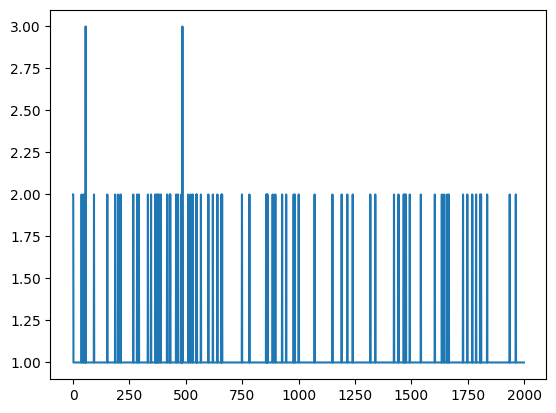

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#plt.plot(episodes, rewards)
plt.plot(episodes, pickup_counts)

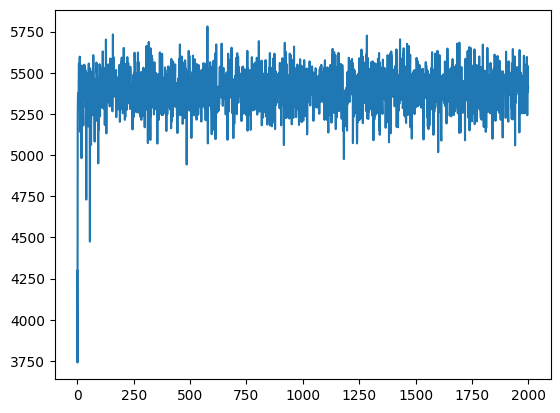

In [ ]:
plt.plot(episodes, rewards)